# Hybrydowe modele

Hybryda to połączenie wyników kilku modeli, które może poprawić ogólną skuteczność i stabilność predykcji. W tym przypadku łączymy wyniki trzech modeli: regresji logistycznej, lasu losowego i drzewa decyzyjnego, aby uzyskać bardziej wiarygodne przewidywania grup Pokemonów.

Hybryda z trzema modelami ma niższą trafność, ponieważ uwzględnia także drzewo decyzyjne, które jest zwykle mniej stabilne i może zwracać bardziej skrajne, mniej zrównoważone prawdopodobieństwa. W efekcie jego wyniki mogą pogarszać średnią ważoną, szczególnie gdy model ten działa słabiej od pozostałych. Dlatego hybryda bez drzewa, oparta tylko na regresji logistycznej i lesie losowym, może osiągać lepszą trafność, ponieważ oba modele dają bardziej stabilne i mają zrównoważone predykcje.

### Importy

In [232]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [233]:
pokemonyMain = pd.read_csv("pokemon.csv")
pokemonyMain.head()

,name,pokemonid,formid,formname,gen,release,type1,type2,species,height,...,defense,spatk,spdef,speed,ev_hp,ev_attack,ev_defense,ev_spatk,ev_spdef,ev_speed
0,bulbasaur,bulbasaur,NaN,NaN,1,red-blue,grass,poison,Seed,0.7,...,49,65,65,45,NaN,NaN,NaN,1.0,NaN,NaN
1,ivysaur,ivysaur,NaN,NaN,1,red-blue,grass,poison,Seed,1.0,...,63,80,80,60,NaN,NaN,NaN,1.0,1.0,NaN
2,venusaur,venusaur,NaN,NaN,1,red-blue,grass,poison,Seed,2.0,...,83,100,100,80,NaN,NaN,NaN,2.0,1.0,NaN
3,venusaur-mega,venusaur,mega,Mega Venusaur,6,x-y,grass,poison,Seed,2.4,...,123,122,120,80,NaN,NaN,NaN,2.0,1.0,NaN
4,charmander,charmander,NaN,NaN,1,red-blue,fire,NaN,Lizard,0.6,...,43,60,50,65,NaN,NaN,NaN,NaN,NaN,1.0


In [234]:
type_to_group = {
    "water": "sredniaki",
    "poison": "sredniaki",
    "grass": "sredniaki",
    "ice": "sredniaki",
    "normal": "sredniaki",
    "bug": "sredniaki",

    "dragon": "elita",

    "electric": "specjalni",
    "psychic": "specjalni",
    "fairy": "specjalni",
    "ghost": "specjalni",
    "fire": "specjalni",

    "fighting": "agresorzy",
    "dark": "agresorzy",
    "flying": "agresorzy",

    "ground": "grubole",
    "rock": "grubole",
    "steel": "grubole",
}

pokemonyMain["group"] = pokemonyMain["type1"].str.lower().map(type_to_group)
pokemonyMain = pokemonyMain.dropna(subset=["group"])
pokemonyMain["group"].value_counts()

group
sredniaki    580
specjalni    310
grubole      160
agresorzy    116
elita         49
Name: count, dtype: int64

In [235]:
pokemonyMain.to_csv("pokemonyMain_groups.csv", index=False)
pokemonyMain_hybryda = pokemonyMain.copy()
pokemonyMain_hybryda = pokemonyMain_hybryda.dropna(subset=[
    "weight",
    "catch_rate",
    "base_exp",
    "group"
])
cechy = pokemonyMain_hybryda[[
    "hp",
    "attack",
    "defense",
    "spatk",
    "spdef",
    "speed",
    "height",
    "weight",
    "catch_rate",
    "base_exp",
    "egg_cycles"
]]
etykieta = pokemonyMain_hybryda["group"]

In [236]:
cecha_train, cecha_test, etykieta_train, etykieta_test = train_test_split(
    cechy,
    etykieta,
    test_size=0.3,
    random_state=42
)

In [237]:
modele = {
    'LR': LogisticRegression(solver='lbfgs', max_iter=10000, random_state=42),
    'RF': RandomForestClassifier(n_estimators=100, random_state=42),
    'DT': DecisionTreeClassifier(max_depth=5,random_state=42)
}

# Rezultaty dla poszczególnych modeli

Wyniki modeli obliczono za pomocą walidacji krzyżowej StratifiedKFold (5 foldów).
Dla każdego modelu policzono accuracy oraz F1 macro.
Następnie podano średnią wartość metryki (mean) i odchylenie standardowe (std), aby ocenić zarówno skuteczność, jak i stabilność modelu.

Walidacja krzyżowa: polega na wielokrotnym dzieleniu danych na część treningową i testową, aby sprawdzić model na kilku różnych podziałach. Dzięki temu ocena jest bardziej wiarygodna i mniej zależy od jednego losowego splitu danych.


Accuracy jest różna od podanych w modelach ponieważ tutaj oceniamy modele na całym zbiorze danych za pomocą walidacji krzyżowej, a nie tylko na zbiorze testowym (train_test_split).

F1 macro jest średnią ważoną F1 score dla każdej klasy, gdzie każda klasa ma równą wagę, niezależnie od jej liczebności. Jest to szczególnie przydatne w przypadku nierównomiernych klas, ponieważ daje równą wagę wszystkim klasom, a nie tylko tym dominującym.

In [238]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

wyniki_modeli = {}

for name, model in modele.items():
    cv_results = cross_validate(
        model,
        cechy,
        etykieta,
        cv=skf,
        scoring={
            "accuracy": "accuracy",
            "f1_macro": "f1_macro"
        },
        n_jobs=-1
    )

    wyniki_modeli[name] = {
        "accuracy_mean": cv_results["test_accuracy"].mean(),
        "accuracy_std": cv_results["test_accuracy"].std(),
        "f1_mean": cv_results["test_f1_macro"].mean(),
        "f1_std": cv_results["test_f1_macro"].std()
    }

    print(f"\nModel: {name}")
    print(f"Accuracy (CV): {wyniki_modeli[name]['accuracy_mean']:.3f} ± {wyniki_modeli[name]['accuracy_std']:.3f}")
    print(f"F1 macro (CV): {wyniki_modeli[name]['f1_mean']:.3f} ± {wyniki_modeli[name]['f1_std']:.3f}")


Model: LR
Accuracy (CV): 0.522 ± 0.036
F1 macro (CV): 0.303 ± 0.036

Model: RF
Accuracy (CV): 0.576 ± 0.022
F1 macro (CV): 0.492 ± 0.025

Model: DT
Accuracy (CV): 0.520 ± 0.034
F1 macro (CV): 0.315 ± 0.028


# Hybryda dla 3 modeli

In [239]:
proba_test = {}                     #proba=probability
for name, model in modele.items():
    model.fit(cecha_train, etykieta_train)
    proba_test[name] = model.predict_proba(cecha_test)

grupy = sorted(etykieta.unique())

srednia_wazona = (proba_test['LR'] + proba_test['RF'] + proba_test['DT']) / 3
hybrid3_pred = np.array(grupy)[np.argmax(srednia_wazona, axis=1)]

trafnosc = accuracy_score(etykieta_test, hybrid3_pred)
avg_pewn = srednia_wazona.max(axis=1).mean()

print(f"Hybryda - trafność:    {trafnosc:.3f}")
print(f"Hybryda - średnia pewność: {avg_pewn:.3f}")

#przyklad dla zubata
sample     = cecha_test.sample(1, random_state=7)
idx = sample.index[0]
pos      = cecha_test.index.get_indexer([idx])[0]

nazwa     = pokemonyMain_hybryda.loc[idx, "name"]
true_grupa = etykieta_test.loc[idx]
pred_grupa = hybrid3_pred[pos]

lr_p = proba_test['LR'][pos]
rf_p = proba_test['RF'][pos]
dt_p = proba_test['DT'][pos]

print(f" ")
print(f"Pokemon: {nazwa:<20} Prawdziwa: {true_grupa:<12} Predykcja: {pred_grupa}")
print(f" ")
print(f"  {'Klasa':<12} {'LR':>8} {'RF':>8} {'DT':>8}   {'Obliczenie':>45}   {'Wynik':>8}")
print(f" ")
for j, label in enumerate(grupy):
    obliczenie = (f"{lr_p[j]:.4f} + "
                  f"{rf_p[j]:.4f} + "
                  f"{dt_p[j]:.4f}")
    wynik = round((lr_p[j] + rf_p[j] + dt_p[j]) / 3,3)
    marker = " ← MAX" if label == pred_grupa else ""
    print(f"  {label:<12} {lr_p[j]:>8.4f} {rf_p[j]:>8.4f} {dt_p[j]:>8.4f}"
          f"   {obliczenie:>45} = {wynik}{marker}")
print()


Hybryda - trafność:    0.539
Hybryda - średnia pewność: 0.552
 
Pokemon: zubat                Prawdziwa: sredniaki    Predykcja: sredniaki
 
  Klasa              LR       RF       DT                                      Obliczenie      Wynik
 
  agresorzy      0.0481   0.0100   0.0360                        0.0481 + 0.0100 + 0.0360 = 0.031
  elita          0.0030   0.0000   0.0000                        0.0030 + 0.0000 + 0.0000 = 0.001
  grubole        0.0681   0.0300   0.0541                        0.0681 + 0.0300 + 0.0541 = 0.051
  specjalni      0.1866   0.0200   0.1081                        0.1866 + 0.0200 + 0.1081 = 0.105
  sredniaki      0.6942   0.9400   0.8018                        0.6942 + 0.9400 + 0.8018 = 0.812 ← MAX



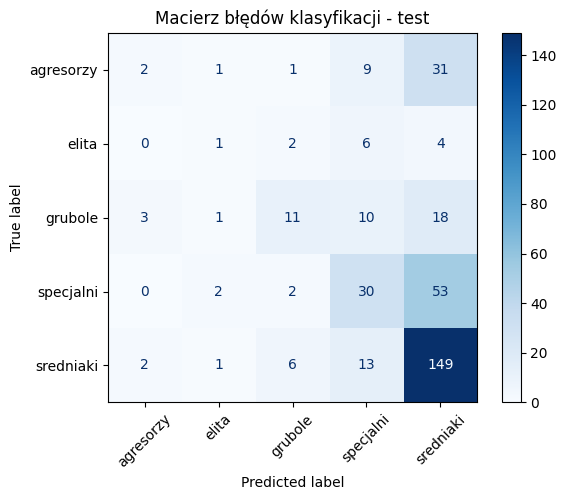

In [240]:
disp = ConfusionMatrixDisplay.from_predictions(
    etykieta_test,
    hybrid3_pred,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Macierz błędów klasyfikacji - test")
plt.savefig("confusion_matrix_test_regresja.png", dpi=300, bbox_inches="tight")
plt.show()

In [241]:
wyniki3 = cecha_test.copy()

wyniki3["prawdziwa_grupa"] = etykieta_test.values
wyniki3["przewidziana_grupa"] = hybrid3_pred

wyniki3["pokemon"] = pokemonyMain.loc[cecha_test.index, "name"].values

print(wyniki3[["pokemon", "prawdziwa_grupa", "przewidziana_grupa"]].head(20))

           pokemon prawdziwa_grupa przewidziana_grupa
953      pheromosa       sredniaki          specjalni
247          yanma       sredniaki          sredniaki
260         pineco       sredniaki          sredniaki
155         horsea       sredniaki          sredniaki
566      rhyperior         grubole            grubole
549   lucario-mega       agresorzy          specjalni
803        flabebe       specjalni          sredniaki
58       vileplume       sredniaki          sredniaki
753       braviary       sredniaki          sredniaki
644         audino       sredniaki          sredniaki
613       oshawott       sredniaki          sredniaki
746      druddigon           elita            grubole
716       frillish       sredniaki          sredniaki
572        leafeon       sredniaki            grubole
380       meditite       agresorzy          sredniaki
70         persian       sredniaki          sredniaki
523       drifloon       specjalni          sredniaki
823        malamar       agr

# Hybryda bez drzewa

In [242]:
proba_test = {}
for name, model in modele.items():
    model.fit(cecha_train, etykieta_train)
    proba_test[name] = model.predict_proba(cecha_test)

grupy = sorted(etykieta.unique())

srednia_wazona2 = (proba_test['LR'] + proba_test['RF']) / 2
hybrid2_pred = np.array(grupy)[np.argmax(srednia_wazona2, axis=1)]

trafnosc2 = accuracy_score(etykieta_test, hybrid2_pred)
avg_pewn2 = srednia_wazona2.max(axis=1).mean()

print(f"Hybryda - trafność:    {trafnosc2:.3f}")
print(f"Hybryda - średnia pewność: {avg_pewn2:.3f}")

#przyklad dla zubata
sample     = cecha_test.sample(1, random_state=7)
idx = sample.index[0]
pos      = cecha_test.index.get_indexer([idx])[0]

nazwa     = pokemonyMain_hybryda.loc[idx, "name"]
true_grupa = etykieta_test.loc[idx]
pred_grupa = hybrid2_pred[pos]

lr_p = proba_test['LR'][pos]
rf_p = proba_test['RF'][pos]
dt_p = proba_test['DT'][pos]

print(f" ")
print(f"Pokemon: {nazwa:<20} Prawdziwa: {true_grupa:<12} Predykcja: {pred_grupa}")
print(f" ")
print(f"  {'Klasa':<12} {'LR':>8} {'RF':>8}   {'Obliczenie':>45}   {'Wynik':>8}")
print(f" ")
for j, label in enumerate(grupy):
    obliczenie = (f"{lr_p[j]:.4f} + "
                  f"{rf_p[j]:.4f} ")
    wynik = round((lr_p[j] + rf_p[j] ) / 2,3)
    marker = " ← MAX" if label == pred_grupa else ""
    print(f"  {label:<12} {lr_p[j]:>8.4f} {rf_p[j]:>8.4f}"
          f"   {obliczenie:>45} = {wynik}{marker}")
print()

Hybryda - trafność:    0.570
Hybryda - średnia pewność: 0.549
 
Pokemon: zubat                Prawdziwa: sredniaki    Predykcja: sredniaki
 
  Klasa              LR       RF                                      Obliczenie      Wynik
 
  agresorzy      0.0481   0.0100                                0.0481 + 0.0100  = 0.029
  elita          0.0030   0.0000                                0.0030 + 0.0000  = 0.001
  grubole        0.0681   0.0300                                0.0681 + 0.0300  = 0.049
  specjalni      0.1866   0.0200                                0.1866 + 0.0200  = 0.103
  sredniaki      0.6942   0.9400                                0.6942 + 0.9400  = 0.817 ← MAX



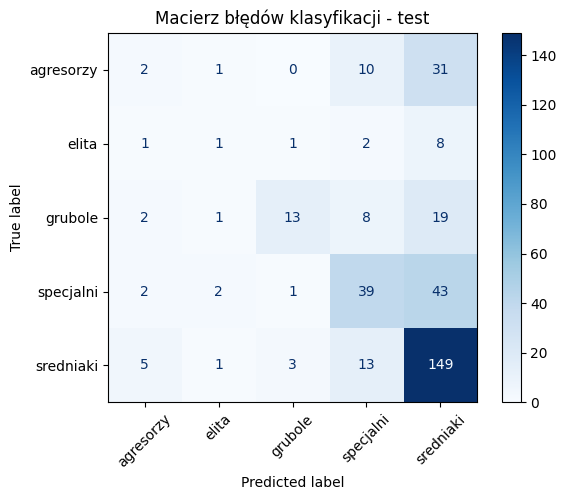

In [243]:
disp = ConfusionMatrixDisplay.from_predictions(
    etykieta_test,
    hybrid2_pred,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Macierz błędów klasyfikacji - test")
plt.savefig("confusion_matrix_test_regresja.png", dpi=300, bbox_inches="tight")
plt.show()

In [244]:
wyniki2 = cecha_test.copy()

wyniki2["prawdziwa_grupa"] = etykieta_test.values
wyniki2["przewidziana_grupa"] = hybrid2_pred

wyniki2["pokemon"] = pokemonyMain.loc[cecha_test.index, "name"].values

print(wyniki2[["pokemon", "prawdziwa_grupa", "przewidziana_grupa"]].head(20))


           pokemon prawdziwa_grupa przewidziana_grupa
953      pheromosa       sredniaki          specjalni
247          yanma       sredniaki          sredniaki
260         pineco       sredniaki          sredniaki
155         horsea       sredniaki          sredniaki
566      rhyperior         grubole            grubole
549   lucario-mega       agresorzy          specjalni
803        flabebe       specjalni          specjalni
58       vileplume       sredniaki          sredniaki
753       braviary       sredniaki          sredniaki
644         audino       sredniaki          sredniaki
613       oshawott       sredniaki          sredniaki
746      druddigon           elita            grubole
716       frillish       sredniaki          sredniaki
572        leafeon       sredniaki            grubole
380       meditite       agresorzy          sredniaki
70         persian       sredniaki          sredniaki
523       drifloon       specjalni          sredniaki
823        malamar       agr